Dataset Loaded Successfully!

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37345

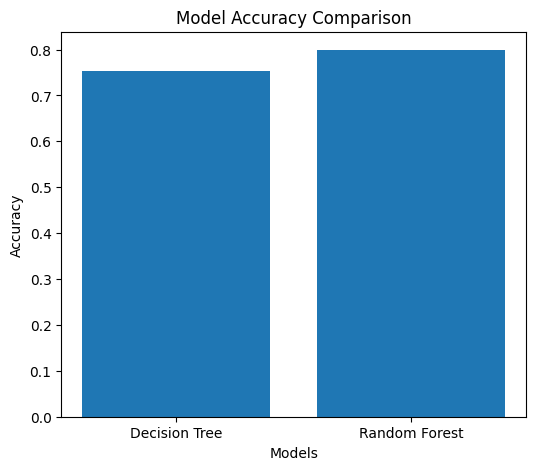

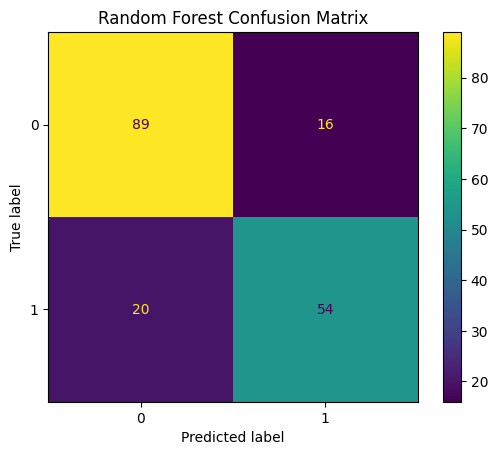

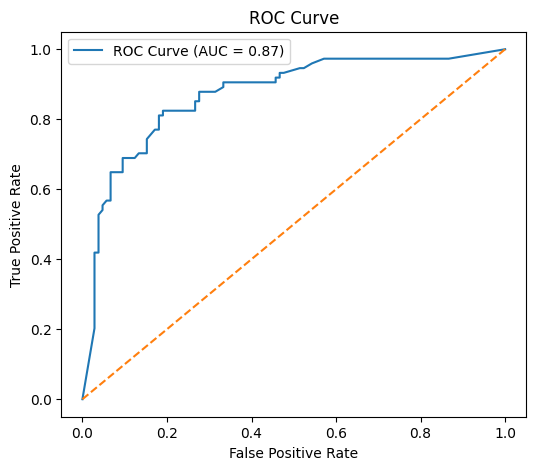


========== FINAL RESULT ==========

Decision Tree Accuracy : 0.7541899441340782
Random Forest Accuracy : 0.7988826815642458

Random Forest performed better.

Project Completed Successfully!


In [1]:
# ============================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve, auc


# ============================================
# LOAD DATASET FROM ONLINE LINK
# ============================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

data = pd.read_csv(url)

print("Dataset Loaded Successfully!\n")

print(data.head())


# ============================================
# DATA PREPROCESSING
# ============================================

# Select important columns
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Fill missing Age values
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Convert categorical data into numerical
encoder = LabelEncoder()

data['Sex'] = encoder.fit_transform(data['Sex'])

print("\nProcessed Data:\n")
print(data.head())


# ============================================
# DEFINE INPUT AND OUTPUT
# ============================================

X = data[['Pclass', 'Sex', 'Age', 'Fare']]

y = data['Survived']


# ============================================
# SPLIT TRAINING AND TESTING DATA
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Size:", len(X_train))
print("Testing Data Size:", len(X_test))


# ============================================
# DECISION TREE MODEL
# ============================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("\nDecision Tree Accuracy:", dt_accuracy)


# ============================================
# RANDOM FOREST MODEL
# ============================================

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:", rf_accuracy)


# ============================================
# COMPARE MODEL ACCURACY
# ============================================

models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()


# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()


# ============================================
# ROC CURVE
# ============================================

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label='ROC Curve (AUC = %0.2f)' % roc_auc
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# ============================================
# FINAL RESULT
# ============================================

print("\n========== FINAL RESULT ==========")

print("\nDecision Tree Accuracy :", dt_accuracy)

print("Random Forest Accuracy :", rf_accuracy)

if rf_accuracy > dt_accuracy:
    print("\nRandom Forest performed better.")
else:
    print("\nDecision Tree performed better.")

print("\nProject Completed Successfully!")